## 1. Kütüphaneler

In [ ]:
# numpy: sayısal hesaplamalar — matris çarpımı, tanh, exp vb.
# Sıfırdan LSTM'yi numpy ile yazacağız: PyTorch'un içinde ne olduğunu görmek için.
import numpy as np

# torch: derin öğrenme — otomatik türev (autograd) + GPU desteği
import torch

# torch.nn: hazır katmanlar — nn.LSTM, nn.Linear, nn.Dropout
import torch.nn as nn

# torch.optim: optimizörler — Adam, SGD, RMSProp
# Ağırlıkları güncellemek için kullanılır.
import torch.optim as optim

# matplotlib: grafik çizimi
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# Tekrarlanabilirlik: sabit tohum → her çalışmada aynı sonuç
np.random.seed(42)
torch.manual_seed(42)

print("✓ NumPy  :", np.__version__)
print("✓ PyTorch:", torch.__version__)
print()
print("numpy   → sıfırdan LSTM için matematiksel işlemler")
print("torch   → PyTorch modeli, eğitim ve GPU desteği")
print("matplotlib → tüm grafikler")


✓ NumPy  : 2.0.2
✓ PyTorch: 2.11.0+cpu

numpy   → sıfırdan LSTM için matematiksel işlemler
torch   → PyTorch modeli, eğitim ve GPU desteği
matplotlib → tüm grafikler


## 2. Aktivasyon Fonksiyonları: Sigmoid ve tanh

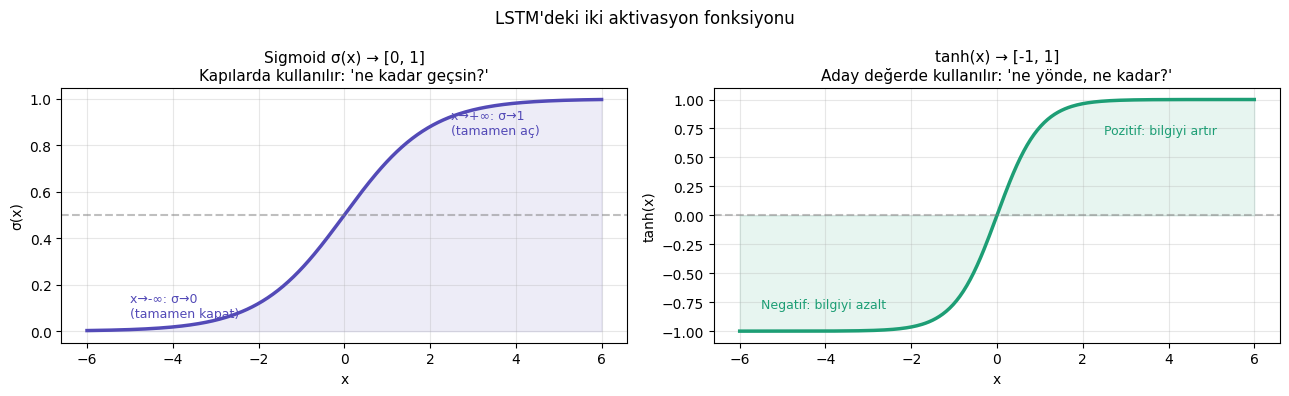

Türev karşılaştırması (gradient akışı açısından kritik):
  sigmoid max türevi : 0.250  (x=0'da)
  tanh    max türevi : 1.000  (x=0'da)

RNN'de zincir: tanh' × tanh' × ... → her adımda ≤0.25 ile çarpılır → hızla sıfır
LSTM'de c_t : gradient sadece f_t ile çarpılır → f_t≈1 ise neredeyse sıfırlanmaz


In [ ]:
def sigmoid(x):
    """
    σ(x) = 1 / (1 + e^{-x})

    np.clip(x, -500, 500) neden?
    → x=-1000 için e^1000 → sonsuz (overflow).
    → clip ile sınırlandırıyoruz: bu aralıkta sigmoid zaten 0 veya 1'e çok yakın,
      sayısal sonuç değişmez ama hesap kararlı kalır.
    """
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))


# Grafik
x = np.linspace(-6, 6, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(x, sigmoid(x), color="#534AB7", linewidth=2.5)
axes[0].axhline(0.5, color="gray", linestyle="--", alpha=0.5)
axes[0].fill_between(x, sigmoid(x), alpha=0.1, color="#534AB7")
axes[0].set_title("Sigmoid σ(x) → [0, 1]\nKapılarda kullanılır: 'ne kadar geçsin?'", fontsize=11)
axes[0].set_xlabel("x"); axes[0].set_ylabel("σ(x)"); axes[0].grid(alpha=0.3)
axes[0].annotate("x→-∞: σ→0\n(tamamen kapat)", xy=(-5, 0.06), fontsize=9, color="#534AB7")
axes[0].annotate("x→+∞: σ→1\n(tamamen aç)",   xy=(2.5, 0.85), fontsize=9, color="#534AB7")

axes[1].plot(x, np.tanh(x), color="#1D9E75", linewidth=2.5)
axes[1].axhline(0, color="gray", linestyle="--", alpha=0.5)
axes[1].fill_between(x, np.tanh(x), alpha=0.1, color="#1D9E75")
axes[1].set_title("tanh(x) → [-1, 1]\nAday değerde kullanılır: 'ne yönde, ne kadar?'", fontsize=11)
axes[1].set_xlabel("x"); axes[1].set_ylabel("tanh(x)"); axes[1].grid(alpha=0.3)
axes[1].annotate("Negatif: bilgiyi azalt", xy=(-5.5, -0.8), fontsize=9, color="#1D9E75")
axes[1].annotate("Pozitif: bilgiyi artır",  xy=(2.5,  0.7),  fontsize=9, color="#1D9E75")

plt.suptitle("LSTM'deki iki aktivasyon fonksiyonu", fontsize=12)
plt.tight_layout()
plt.savefig("/tmp/activations.png", dpi=120, bbox_inches="tight")
plt.show()

print("Türev karşılaştırması (gradient akışı açısından kritik):")
print(f"  sigmoid max türevi : {sigmoid(0)*(1-sigmoid(0)):.3f}  (x=0'da)")
print(f"  tanh    max türevi : {1-np.tanh(0)**2:.3f}  (x=0'da)")
print()
print("RNN'de zincir: tanh' × tanh' × ... → her adımda ≤0.25 ile çarpılır → hızla sıfır")
print("LSTM'de c_t : gradient sadece f_t ile çarpılır → f_t≈1 ise neredeyse sıfırlanmaz")


## 3. VanillaSTMCell

In [ ]:
class VanillaLSTMCell:
    """
    Tek bir LSTM hücresi — sıfırdan, sadece NumPy ile.
    PyTorch kullanmaz: formülün tam olarak ne yaptığını görmek için.

    İki durum taşır:
        h : gizli durum (hidden state)  — kısa vadeli hafıza
        c : hücre durumu (cell state)   — uzun vadeli hafıza
    """

    # ─── __init__: ağırlıkları başlat ────────────────────────────────────
    def __init__(self, input_size: int, hidden_size: int):
        """
        Parametreler:
            input_size  (D): her zaman adımındaki girdi boyutu
            hidden_size (H): gizli/hücre durumu boyutu

        Neden küçük başlangıç (scale=0.1)? learning rate
        → Büyük değerler sigmoid/tanh'ı doygunluğa sokar
          → gradient sıfıra düşer → model öğrenemez.
        → 0.1 ile başlayınca gradyanlar sağlıklı akar.

        Neden [h_{t-1}, x_t] birleştirilir?
        → Her kapı hem geçmişe (h) hem mevcut girdiye (x) bakmalı.
        → Birleştirince tek matris çarpımı yeterli:
          W · [h, x] = W_h·h + W_x·x
        → W şekli: (H, H+D) — hem h hem x'i kapsıyor
        """
        rng   = np.random.default_rng(42)
        H, D  = hidden_size, input_size
        scale = 0.1

        # ── 4 Kapı Ağırlık Matrisleri (H, H+D) ──────────────────────────
        # Unutma kapısı: c_{t-1}'den ne kadar geçsin?  0=sil 1=koru
        self.W_f = rng.standard_normal((H, H + D)) * scale

        # Giriş kapısı: yeni bilgiden ne kadar eklensin?  0=ekleme 1=ekle
        self.W_i = rng.standard_normal((H, H + D)) * scale

        # Aday değer: eklenecek ham bilgi  [-1,1] arası  tanh kullanır
        self.W_g = rng.standard_normal((H, H + D)) * scale

        # Çıkış kapısı: hücreden ne kadar çıksın?  0=gizle 1=göster
        self.W_o = rng.standard_normal((H, H + D)) * scale

        # ── Bias Vektörleri (H,) ─────────────────────────────────────────
        # Unutma biası neden 1.0 (diğerleri 0)?
        # → Eğitim başında modelin "unut" kararı vermesini istemiyoruz.
        # → b_f=1 → sigmoid(... + 1) ≈ 0.73 → başlangıçta hafızayı koru.
        # → Uygulama trick'i: eğitimi hızlandırır.
        self.b_f = np.ones(H)    # ← sadece bu 1, diğerleri sıfır
        self.b_i = np.zeros(H)
        self.b_g = np.zeros(H)
        self.b_o = np.zeros(H)

        self.hidden_size = H
        self.input_size  = D

    # ─── Yardımcı: iki vektörü birleştir ────────────────────────────────
    def _concat(self, h_prev, x_t):
        """
        h_prev (H,) + x_t (D,) → combined (H+D,)

        np.concatenate: iki diziyi arka arkaya ekler.
        Örnek: h=[0.1,-0.3] x=[0.5,0.2,-0.1] → [0.1,-0.3,0.5,0.2,-0.1]
        """
        return np.concatenate([h_prev, x_t])

    # ─── KAPI 1: Unutma Kapısı ───────────────────────────────────────────
    def forget_gate(self, combined):
        """
        f_t = σ( W_f · combined + b_f )   → [0,1]^H

        SORU: c_{t-1}'den (eski hafıza) ne kadar tutalım?
          f_t[j]=0 → j. boyuttaki eski hafızayı TAMAMEN SİL
          f_t[j]=1 → j. boyuttaki eski hafızayı AYNEN KORU

        Gerçek örnek: "Ali doktordur. Ali [yeni kişi] mühendistir."
        → 'Ali' değişince eski mesleği unutmak gerekir.
        → Unutma kapısı bunu öğrenir.

        W_f @ combined: (H, H+D) @ (H+D,) → (H,)  matris-vektör çarpımı
        + b_f         : (H,) + (H,) → (H,)          bias ekle
        sigmoid(...)  : (H,) → (H,)  her eleman [0,1]'e sıkıştır
        """
        return sigmoid(self.W_f @ combined + self.b_f)

    # ─── KAPI 2: Giriş Kapısı ────────────────────────────────────────────
    def input_gate(self, combined):
        """
        i_t = σ( W_i · combined + b_i )   → [0,1]^H

        SORU: Aday değerden (g_t) ne kadarını ekleyelim?
          i_t[j]=0 → bu güncellemeyi YOKSAY
          i_t[j]=1 → bu güncellemeyi KABUL ET

        Sezgi: i_t 'ne kadar dikkat et?' — g_t 'ne öğrenmek istiyorum?'
        Hücre güncellemesi: i_t ⊙ g_t = 'filtrelenmiş öğrenme'
        """
        return sigmoid(self.W_i @ combined + self.b_i)

    # ─── KAPI 3: Aday Değer ──────────────────────────────────────────────
    def candidate(self, combined):
        """
        g_t = tanh( W_g · combined + b_g )   → [-1,1]^H

        NOT: Teknik olarak 'kapı' değil — sigmoid değil tanh kullanır.
             Bu yüzden [0,1] değil [-1,1] aralığında.
             'cell gate' veya 'g' olarak anılır.

        Neden tanh?
        → Sigmoid sadece 'ne kadar' sorusunu yanıtlar (0..1).
        → tanh 'ne yönde ve ne kadar' sorusunu yanıtlar (-1..+1).
        → Hücreyi hem artırabilir (+) hem azaltabilir (-).

        Örnek: sıcaklık tahmini için g_t=-0.8 → 'sıcaklık düşüyor' sinyali
        """
        return np.tanh(self.W_g @ combined + self.b_g)

    # ─── KAPI 4: Çıkış Kapısı ────────────────────────────────────────────
    def output_gate(self, combined):
        """
        o_t = σ( W_o · combined + b_o )   → [0,1]^H

        SORU: c_t'nin (tüm uzun hafıza) kaçını h_t'ye yansıtalım?
          o_t[j]=0 → c_t'nin j. boyutunu GİZLE
          o_t[j]=1 → c_t'nin j. boyutunu GÖSTER

        Ardından: h_t = o_t ⊙ tanh(c_t)
        tanh(c_t): hücre durumunu -1..+1'e normalize eder
        o_t      : ne kadarının h_t'ye geçeceğini filtreler
        """
        return sigmoid(self.W_o @ combined + self.b_o)

    # ─── forward_step: TEK ADIM ──────────────────────────────────────────
    def forward_step(self, x_t, h_prev, c_prev):
        """
        Tek bir zaman adımını işler.

        Parametreler:
            x_t    (D,): mevcut adımın girdisi
            h_prev (H,): önceki gizli durum   — kısa hafıza
            c_prev (H,): önceki hücre durumu  — uzun hafıza

        Döndürür:
            h_t  (H,): yeni gizli durum
            c_t  (H,): yeni hücre durumu
            gates dict: kapı değerleri (görselleştirme için)

        Adım adım:
        ① Girdiyi birleştir
        ② Unutma: eski hafızadan ne kalsın?
        ③ Giriş: ne kadar yeni bilgi eklensin?
        ④ Aday: hangi yeni bilgi eklensin?
        ⑤ Çıkış: hücreyi ne kadar göster?
        ⑥ Hücre durumunu güncelle
        ⑦ Gizli durumu güncelle
        """
        # ① Birleştir: (H,) + (D,) → (H+D,)
        combined = self._concat(h_prev, x_t)

        # ② Unutma: f_t ∈ [0,1]^H — "eskiyi ne kadar unut?"
        f_t = self.forget_gate(combined)

        # ③ Giriş: i_t ∈ [0,1]^H — "yeniden ne kadar ekle?"
        i_t = self.input_gate(combined)

        # ④ Aday: g_t ∈ [-1,1]^H — "ne ekleyeceğim?"
        g_t = self.candidate(combined)

        # ⑤ Çıkış: o_t ∈ [0,1]^H — "hücreyi ne kadar göster?"
        o_t = self.output_gate(combined)

        # ⑥ Hücre durumu güncelle
        # c_t = f_t ⊙ c_{t-1}  +  i_t ⊙ g_t
        #       ───────────────    ────────────
        #       eski hafıza        yeni bilgi
        #       (f_t ile filtreli) (i_t ile kapılı)
        #
        # ⊙ = eleman-eleman çarpım (Hadamard product)
        # numpy'da bu sadece * operatörü ile yapılır (matris değil vektör)
        #
        # GRADIENT NEDEN KAYBOLMUYOR?
        # dc_t/dc_{t-1} = f_t  (sadece tek çarpma, tanh zinciri yok!)
        # f_t ≈ 1 ise gradient neredeyse bölünmeden geçer.
        c_t = f_t * c_prev  +  i_t * g_t

        # ⑦ Gizli durum güncelle
        # h_t = o_t ⊙ tanh(c_t)
        # tanh(c_t): hücreyi -1..+1'e normalize et
        # o_t      : 'hangi boyutları dışarı ver?' filtresi
        h_t = o_t * np.tanh(c_t)

        gates = {"f": f_t, "i": i_t, "g": g_t, "o": o_t}
        return h_t, c_t, gates

    # ─── forward_sequence: TAM DİZİ ──────────────────────────────────────
    def forward_sequence(self, X):
        """
        Tam bir diziyi işler — forward_step'i her adım için çağırır.

        Parametre:
            X (seq_len, D): tüm zaman adımlarının girdisi

        Döndürür:
            H (seq_len, H): her adımın gizli durumu
            C (seq_len, H): her adımın hücre durumu
            gates_list    : her adımın kapı değerleri

        Neden .copy()?
        → h ve c her adımda GÜNCELLENİR (aynı nesne).
        → .copy() olmadan listedeki tüm elemanlar son değeri gösterir.
        → .copy() anlık değeri saklar.
        """
        seq_len, _ = X.shape

        # Başlangıç: h_0 = sıfır, c_0 = sıfır
        # 'Model hiçbir şey bilmiyor' anlamına gelir.
        h = np.zeros(self.hidden_size)
        c = np.zeros(self.hidden_size)

        H_list, C_list, gates_list = [], [], []

        for t in range(seq_len):
            x_t  = X[t]                              # t. adım girdisi
            h, c, gates = self.forward_step(x_t, h, c)  # h ve c güncelleniyor
            H_list.append(h.copy())   # anlık değeri kaydet
            C_list.append(c.copy())
            gates_list.append(gates)

        return np.array(H_list), np.array(C_list), gates_list


# ─── Hızlı test ──────────────────────────────────────────────────────────
INPUT_SIZE  = 6
HIDDEN_SIZE = 12
SEQ_LEN     = 10

cell   = VanillaLSTMCell(INPUT_SIZE, HIDDEN_SIZE)
X_test = np.random.randn(SEQ_LEN, INPUT_SIZE)
H_out, C_out, gates_all = cell.forward_sequence(X_test)

print(f"Girdi  X : {X_test.shape}")
print(f"Gizli  H : {H_out.shape}   → her adımın h_t'si")
print(f"Hücre  C : {C_out.shape}   → her adımın c_t'si")
print()
print("İlk 3 adımın kapı ortalamaları:")
for t in range(3):
    g = gates_all[t]
    print(f"  t={t}:  f={g['f'].mean():.3f} (unut)  "
          f"i={g['i'].mean():.3f} (giriş)  "
          f"o={g['o'].mean():.3f} (çıkış)")


Girdi  X : (10, 6)
Gizli  H : (10, 12)   → her adımın h_t'si
Hücre  C : (10, 12)   → her adımın c_t'si

İlk 3 adımın kapı ortalamaları:
  t=0:  f=0.724 (unut)  i=0.499 (giriş)  o=0.494 (çıkış)
  t=1:  f=0.742 (unut)  i=0.504 (giriş)  o=0.486 (çıkış)
  t=2:  f=0.721 (unut)  i=0.495 (giriş)  o=0.509 (çıkış)


## 4. Gate Görselleştirmesi

/tmp/ipykernel_2505/2315840393.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


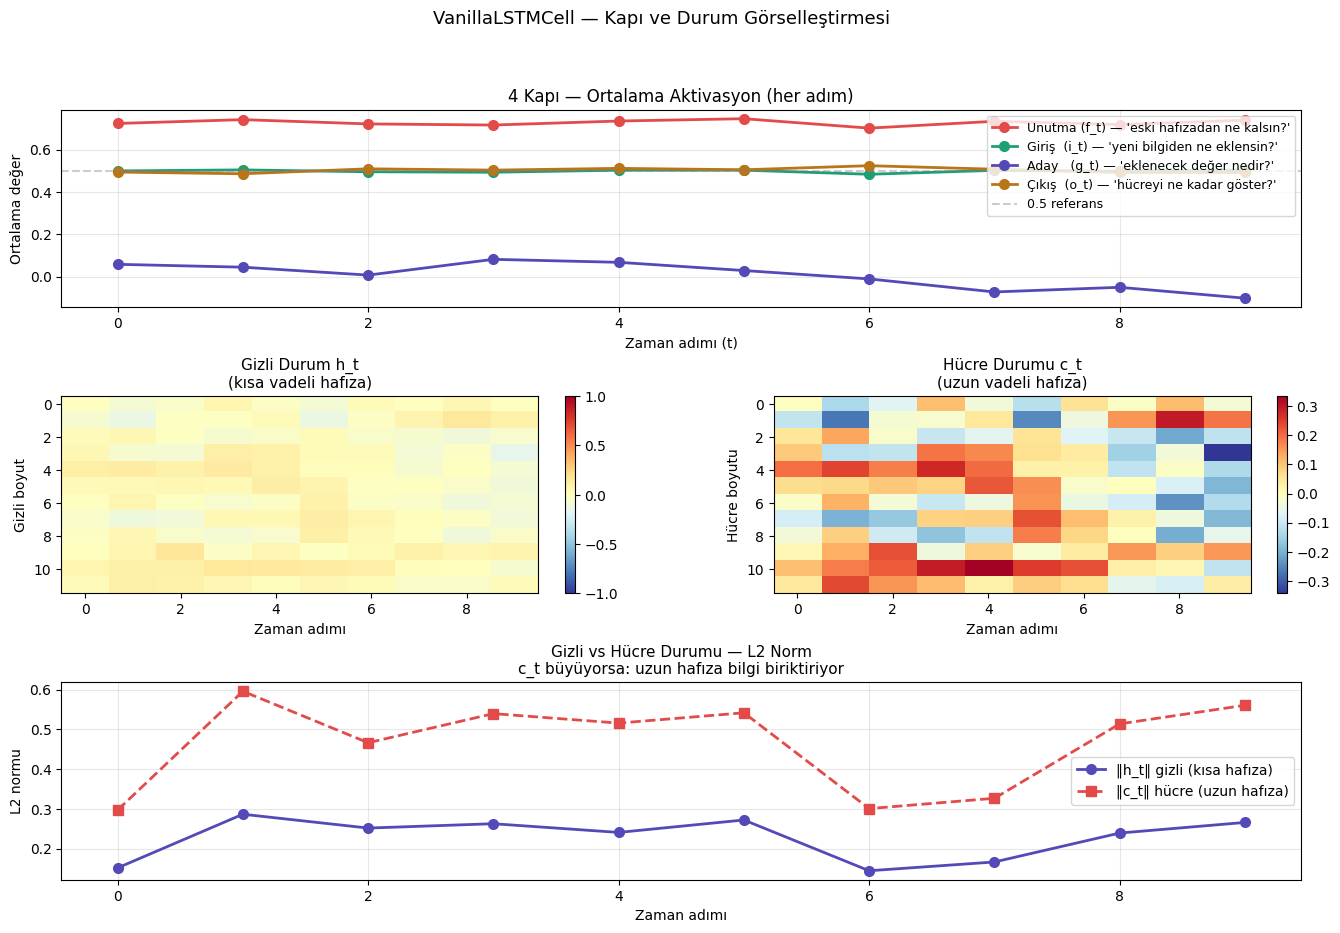

Görselleştirme ✓


In [ ]:
gate_means = {k: [] for k in ["f", "i", "g", "o"]}
for step_gates in gates_all:
    for k in gate_means:
        gate_means[k].append(step_gates[k].mean())

fig = plt.figure(figsize=(16, 10))
gs  = GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

# ── Kapı aktivasyonları zaman içinde ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
colors_g = {"f": "#E24B4A", "i": "#1D9E75", "g": "#534AB7", "o": "#BA7517"}
labels_g = {
    "f": "Unutma (f_t) — 'eski hafızadan ne kalsın?'",
    "i": "Giriş  (i_t) — 'yeni bilgiden ne eklensin?'",
    "g": "Aday   (g_t) — 'eklenecek değer nedir?'",
    "o": "Çıkış  (o_t) — 'hücreyi ne kadar göster?'"
}
for k, vals in gate_means.items():
    ax1.plot(vals, "o-", label=labels_g[k], color=colors_g[k], linewidth=2, markersize=7)
ax1.axhline(0.5, color="gray", linestyle="--", alpha=0.4, label="0.5 referans")
ax1.set_title("4 Kapı — Ortalama Aktivasyon (her adım)", fontsize=12)
ax1.set_xlabel("Zaman adımı (t)"); ax1.set_ylabel("Ortalama değer")
ax1.legend(fontsize=9, loc="upper right"); ax1.grid(alpha=0.3)

# ── h_t ısı haritası ─────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
im2 = ax2.imshow(H_out.T, aspect="auto", cmap="RdYlBu_r", vmin=-1, vmax=1)
ax2.set_title("Gizli Durum h_t\n(kısa vadeli hafıza)", fontsize=11)
ax2.set_xlabel("Zaman adımı"); ax2.set_ylabel("Gizli boyut")
plt.colorbar(im2, ax=ax2, fraction=0.046)

# ── c_t ısı haritası ─────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
im3 = ax3.imshow(C_out.T, aspect="auto", cmap="RdYlBu_r")
ax3.set_title("Hücre Durumu c_t\n(uzun vadeli hafıza)", fontsize=11)
ax3.set_xlabel("Zaman adımı"); ax3.set_ylabel("Hücre boyutu")
plt.colorbar(im3, ax=ax3, fraction=0.046)

# ── Norm karşılaştırması ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, :])
h_norms = [np.linalg.norm(H_out[t]) for t in range(SEQ_LEN)]
c_norms = [np.linalg.norm(C_out[t]) for t in range(SEQ_LEN)]
ax4.plot(h_norms, "o-", label="‖h_t‖ gizli (kısa hafıza)", color="#534AB7", lw=2, ms=7)
ax4.plot(c_norms, "s--", label="‖c_t‖ hücre (uzun hafıza)", color="#E24B4A", lw=2, ms=7)
ax4.set_title("Gizli vs Hücre Durumu — L2 Norm\n"
              "c_t büyüyorsa: uzun hafıza bilgi biriktiriyor", fontsize=11)
ax4.set_xlabel("Zaman adımı"); ax4.set_ylabel("L2 normu")
ax4.legend(fontsize=10); ax4.grid(alpha=0.3)

plt.suptitle("VanillaLSTMCell — Kapı ve Durum Görselleştirmesi", fontsize=13)
plt.tight_layout()
plt.savefig("/tmp/lstm_gates_detail.png", dpi=120, bbox_inches="tight")
plt.show()
print("Görselleştirme ✓")


## 5. Veri Hazırlığı ve NLP Ön İşleme (Spam SMS Verisi)

In [ ]:
import pandas as pd
from collections import Counter
from torch.utils.data import Dataset, DataLoader

# 1. Veriyi Yükle
df = pd.read_csv('/content/Spam_SMS.csv')

# Sütun isimlerini otomatik bulmaya çalış
label_col = next((col for col in df.columns if col.lower() in ['v1', 'label', 'class', 'category']), df.columns[0])
text_col = next((col for col in df.columns if col.lower() in ['v2', 'text', 'message', 'sms']), df.columns[1])

print(f"Etiket sütunu: '{label_col}', Metin sütunu: '{text_col}' olarak belirlendi.")
display(df[[label_col, text_col]].head())

# Etiketleri sayıya çevir (spam=1, ham/normal=0)
df['label_num'] = df[label_col].apply(lambda x: 1 if str(x).strip().lower() == 'spam' else 0)

# 2. Basit Tokenization ve Kelime Dağarcığı (Vocabulary) Oluşturma
texts = df[text_col].astype(str).values
labels = df['label_num'].values

# Tüm kelimeleri küçük harfe çevir ve ayır
words = ' '.join(texts).lower().split()
word_counts = Counter(words)

# En çok geçen 5000 kelimeyi al
VOCAB_SIZE = 5000
common_words = [word for word, count in word_counts.most_common(VOCAB_SIZE - 2)]

# Pad (0) ve Unknown (1) tokenları ekle
word_to_idx = {word: idx + 2 for idx, word in enumerate(common_words)}
word_to_idx['<PAD>'] = 0
word_to_idx['<UNK>'] = 1

# Cümleleri sayılara (index) çevir
MAX_SEQ_LEN = 50
sequences = []
for text in texts:
    seq = [word_to_idx.get(word, 1) for word in text.lower().split()][:MAX_SEQ_LEN]
    # Padding: Eğer cümle kısa ise sonuna 0 ekle
    seq += [0] * (MAX_SEQ_LEN - len(seq))
    sequences.append(seq)

# 3. PyTorch Dataset ve DataLoader
class SMSDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

dataset = SMSDataset(sequences, labels)

# Veriyi eğitim ve test olarak ayırma (%80 - %20)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"\nEğitim verisi: {len(train_dataset)} adet, Test verisi: {len(test_dataset)} adet")
print(f"Kelime Dağarcığı Boyutu: {len(word_to_idx)}")

Etiket sütunu: 'Class', Metin sütunu: 'Message' olarak belirlendi.


,Class,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



Eğitim verisi: 4459 adet, Test verisi: 1115 adet
Kelime Dağarcığı Boyutu: 5000


## 6. PyTorch LSTM Modeli Oluşturma (Metin Sınıflandırma)

In [ ]:
class LSTMTextClassifier(nn.Module):
    """
    Metin verisi için Embedding katmanı eklenmiş LSTM modeli.
    """
    def __init__(self, vocab_size, embed_size, hidden_size, num_classes, num_layers=2, dropout=0.3):
        super().__init__()

        # Kelime indekslerini yoğun (dense) vektörlere çevirir
        self.embedding = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_size, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size  = embed_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0,
        )

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x boyutu: (batch_size, seq_len)
        embedded = self.embedding(x)  # (batch_size, seq_len, embed_size)

        output, (h_n, c_n) = self.lstm(embedded)

        # Son zaman adımının çıktısını al
        last_hidden = h_n[-1]         # (batch_size, hidden_size)
        last_hidden = self.dropout(last_hidden)

        logits = self.fc(last_hidden) # (batch_size, num_classes)
        return logits

# Modeli başlat
EMBED_SIZE = 32
HID_SIZE = 64
N_CLASSES = 2  # Spam ve Ham

model_sms = LSTMTextClassifier(
    vocab_size=len(word_to_idx),
    embed_size=EMBED_SIZE,
    hidden_size=HID_SIZE,
    num_classes=N_CLASSES
)
print(model_sms)

LSTMTextClassifier(
  (embedding): Embedding(5000, 32, padding_idx=0)
  (lstm): LSTM(32, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=2, bias=True)
)


## 7. Model Eğitimi ve Değerlendirme (Spam SMS)

In [ ]:
EPOCHS = 10
LR = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_sms.parameters(), lr=LR)

print(f"{'Epoch':>6}  {'Eğitim Kaybı':>15}  {'Eğitim Doğruluk':>20}")
print("─" * 50)

train_losses, train_accs = [], []

for epoch in range(1, EPOCHS + 1):
    model_sms.train()
    epoch_loss = 0
    correct = 0
    total = 0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()

        logits = model_sms(batch_x)
        loss = criterion(logits, batch_y)

        loss.backward()
        nn.utils.clip_grad_norm_(model_sms.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()

        preds = logits.argmax(dim=1)
        correct += (preds == batch_y).sum().item()
        total += batch_y.size(0)

    avg_loss = epoch_loss / len(train_loader)
    avg_acc = (correct / total) * 100

    train_losses.append(avg_loss)
    train_accs.append(avg_acc)

    print(f"{epoch:>6}  {avg_loss:>15.4f}  {avg_acc:>19.2f}%")

print("\nEğitim tamamlandı ✓")

# Test verisinde değerlendirme
model_sms.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for batch_x, batch_y in test_loader:
        logits = model_sms(batch_x)
        preds = logits.argmax(dim=1)
        test_correct += (preds == batch_y).sum().item()
        test_total += batch_y.size(0)

print(f"\nTest Doğruluğu: {(test_correct / test_total) * 100:.2f}%")

 Epoch     Eğitim Kaybı       Eğitim Doğruluk
──────────────────────────────────────────────────
     1           0.4481                86.03%
     2           0.3975                86.50%
     3           0.4020                86.50%
     4           0.3961                86.50%
     5           0.3970                86.50%
     6           0.3930                86.50%
     7           0.2897                88.27%
     8           0.1464                95.58%
     9           0.1138                97.11%
    10           0.0931                97.69%

Eğitim tamamlandı ✓

Test Doğruluğu: 96.59%


## 8. Genel Amaçlı LSTM Sınıflandırıcı Mimarisi

In [ ]:
class LSTMClassifier(nn.Module):
    """
    Dizi → etiket sınıflandırması.
    Mimari: Girdi → LSTM (2 katman) → Dropout → Linear → Sınıf

    nn.Module'den neden kalıtım?
    → PyTorch'a 'bu bir sinir ağıdır' diyoruz.
    → .parameters(), .train(), .eval() metodlarını otomatik kazanıyoruz.
    → model(x) çağrısı otomatik olarak forward(x)'i çalıştırır.
    """

    def __init__(self, input_size, hidden_size, num_classes,
                 num_layers=2, dropout=0.3):
        """
        super().__init__() neden zorunlu?
        → nn.Module'ün __init__'ini çağırır — iç kayıt defterini kurar.
        → Olmadan 'Module not initialized' hatası alırız.
        """
        super().__init__()

        # nn.LSTM parametreleri ────────────────────────────────────────────
        # input_size   : her adımdaki özellik sayısı
        # hidden_size  : LSTM'nin iç boyutu (büyük → kapasite↑, overfit riski↑)
        # num_layers   : yığılmış LSTM — katman 1'in h_t çıktısı katman 2'nin girdisi
        # batch_first  : True → (batch, seq, feat) — daha sezgisel
        #                False → (seq, batch, feat) — PyTorch'un eski varsayılanı
        # dropout      : katmanlar ARASI — son katmana uygulanmaz
        #                num_layers=1 ise 0 olmalı (tek katmanda anlamsız)
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0,
        )

        # nn.Dropout(p): eğitimde nöronların p oranını rastgele sıfırlar.
        # → Model tek bir nörona bağımlı olamaz → genelleme iyileşir.
        # → model.eval() modunda otomatik KAPANIR (test'te etki yok).
        self.dropout = nn.Dropout(dropout)

        # nn.Linear(in, out): tam bağlı katman
        # Son LSTM katmanının h_T'sini (hidden_size,) → (num_classes,) çevirir.
        # Çıktı: 'logit' = ham skor (softmax uygulanmamış)
        # CrossEntropyLoss içeride softmax yapar, biz yapmıyoruz.
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        """
        İleri geçiş — model(x) çağrısında otomatik çalışır.

        x : (batch_size, seq_len, input_size)

        PyTorch autograd bu fonksiyonun her işlemini izler.
        backward() çağrısında tüm türevler otomatik hesaplanır.
        """
        # LSTM çalıştır
        # output : (batch, seq_len, hidden) — her adımın h_t'si
        # h_n    : (num_layers, batch, hidden) — son gizli durum
        # c_n    : (num_layers, batch, hidden) — son hücre durumu
        output, (h_n, c_n) = self.lstm(x)

        # h_n[-1]: son LSTM katmanının son zaman adımındaki durumu
        # Bu vektör tüm diziyi 'özetler'.
        # Şekil: (batch, hidden_size)
        last_hidden = h_n[-1]

        # Dropout (sadece eğitimde aktif)
        last_hidden = self.dropout(last_hidden)

        # Sınıf skorları: (batch, hidden) → (batch, num_classes)
        logits = self.fc(last_hidden)
        return logits

    def get_all_hidden(self, x):
        """Tüm adımların h_t'sini döndür (analiz için)."""
        with torch.no_grad():
            output, (h_n, c_n) = self.lstm(x)
        return output, h_n, c_n


# Model oluştur ve parametre sayısını incele
model_clf = LSTMClassifier(input_size=10, hidden_size=64,
                            num_classes=3, num_layers=2, dropout=0.3)
print(model_clf)
print()

for name, param in model_clf.named_parameters():
    print(f"  {name:35s}  şekil={str(tuple(param.shape)):20s}  "
          f"{param.numel():>8,} parametre")

total = sum(p.numel() for p in model_clf.parameters())
print(f"\n  TOPLAM: {total:,} parametre")
print()
print("LSTM parametre formülü: 4 × H × (H + D) + 4 × H")
H, D = 64, 10
print(f"  = 4 × {H} × ({H} + {D}) + 4 × {H} = {4*H*(H+D)+4*H:,}  (1. katman)")


LSTMClassifier(
  (lstm): LSTM(10, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)

  lstm.weight_ih_l0                    şekil=(256, 10)                2,560 parametre
  lstm.weight_hh_l0                    şekil=(256, 64)               16,384 parametre
  lstm.bias_ih_l0                      şekil=(256,)                     256 parametre
  lstm.bias_hh_l0                      şekil=(256,)                     256 parametre
  lstm.weight_ih_l1                    şekil=(256, 64)               16,384 parametre
  lstm.weight_hh_l1                    şekil=(256, 64)               16,384 parametre
  lstm.bias_ih_l1                      şekil=(256,)                     256 parametre
  lstm.bias_hh_l1                      şekil=(256,)                     256 parametre
  fc.weight                            şekil=(3, 64)                    192 parametre
  fc.bias                             

## 9. İleri Düzey Eğitim Döngüsü ve Sentetik Veri ile Test

 Epoch     Kayıp    Doğruluk            LR
──────────────────────────────────────────────
    10    1.0070       52.3%      0.005000
    20    0.8090       66.4%      0.002500
    30    0.6112       76.6%      0.002500
    40    0.3411       90.6%      0.001250
    50    0.2284       92.2%      0.001250
    60    0.1282       95.3%      0.000625
    70    0.0842       96.9%      0.000625
    80    0.0699       97.7%      0.000313

Eğitim tamamlandı ✓


/tmp/ipykernel_2505/1607736910.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


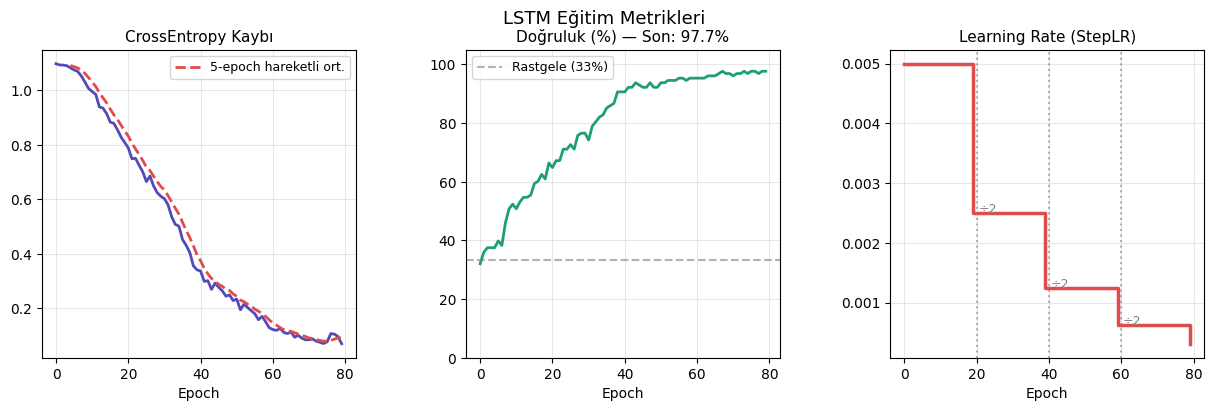

In [ ]:
BATCH, SEQ_LEN, IN_SIZE = 128, 50, 10
HID_SIZE, N_CLASSES     = 64, 3
EPOCHS, LR              = 80, 5e-3

# Sentetik veri — rastgele girdi ve etiket
X_train = torch.randn(BATCH, SEQ_LEN, IN_SIZE)
y_train = torch.randint(0, N_CLASSES, (BATCH,))

model_lstm = LSTMClassifier(IN_SIZE, HID_SIZE, N_CLASSES)

# CrossEntropyLoss: çok sınıflı standart kayıp
# İçeride: softmax → log → negatif log likelihood
# L = -log( exp(logit[gerçek]) / Σ exp(logit[i]) )
criterion = nn.CrossEntropyLoss()

# Adam: her parametre için adaptif learning rate
# weight_decay=1e-4: L2 regularization — büyük ağırlıkları cezalandır
optimizer = optim.Adam(model_lstm.parameters(), lr=LR, weight_decay=1e-4)

# StepLR: her 20 epoch'ta lr'yi gamma=0.5 ile çarp (yarıya indir)
# epoch 0-19: 0.005 → epoch 20-39: 0.0025 → epoch 40-59: 0.00125 ...
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

history = {"loss": [], "acc": [], "lr": []}
print(f"{'Epoch':>6}  {'Kayıp':>8}  {'Doğruluk':>10}  {'LR':>12}")
print("─" * 46)

for epoch in range(1, EPOCHS + 1):

    # ① model.train(): Dropout ve BatchNorm'u aktif et
    #    model.eval()'den sonra eğitime dönünce MUTLAKA çağrılmalı
    model_lstm.train()

    # ② Gradyanları sıfırla
    #    PyTorch varsayılan olarak gradyanları BİRİKTİRİR.
    #    Sıfırlamazsak önceki adımın gradyanları eklenir → yanlış güncelleme.
    optimizer.zero_grad()

    # ③ İleri geçiş
    #    Bu satır computation graph oluşturur.
    #    PyTorch her işlemi kaydeder: backward() için.
    logits = model_lstm(X_train)   # (BATCH, N_CLASSES)

    # ④ Kayıp hesapla
    #    logits: (128, 3) raw skorlar
    #    y_train: (128,) gerçek sınıf indeksleri
    loss = criterion(logits, y_train)

    # ⑤ Geri yayılım (BPTT — Backpropagation Through Time)
    #    Zincir kuralıyla her parametrenin ∂loss/∂param değerini hesaplar.
    #    LSTM için gradient zaman boyunca geriye taşınır.
    loss.backward()

    # ⑥ Gradient kırpma
    #    Tüm parametrelerin gradient vektörünün L2 normu max_norm'u aşarsa
    #    ölçekler: grad = grad × (max_norm / ‖grad‖)
    #    Örnek: norm=10, max_norm=1 → tüm gradyanlar 10'a bölünür.
    #    LSTM eğitiminde stabilite için kritik.
    nn.utils.clip_grad_norm_(model_lstm.parameters(), max_norm=1.0)

    # ⑦ Ağırlıkları güncelle
    #    Adam: param = param - lr × m̂ / (√v̂ + ε)
    #    m̂: gradyan hareketli ortalaması (momentum)
    #    v̂: gradyan kare hareketli ortalaması (adaptif ölçekleme)
    optimizer.step()

    # ⑧ Learning rate scheduler
    scheduler.step()

    # Doğruluk hesapla (gradient izlemeden)
    with torch.no_grad():
        preds = logits.argmax(dim=1)   # en yüksek skor → tahmin
        acc   = (preds == y_train).float().mean().item() * 100

    current_lr = scheduler.get_last_lr()[0]
    history["loss"].append(loss.item())
    history["acc"].append(acc)
    history["lr"].append(current_lr)

    if epoch % 10 == 0:
        print(f"{epoch:>6}  {loss.item():>8.4f}  {acc:>9.1f}%  {current_lr:>12.6f}")

print("\nEğitim tamamlandı ✓")

# Eğitim eğrisi
fig = plt.figure(figsize=(15, 4))
gs  = GridSpec(1, 3, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
ax1.plot(history["loss"], color="#534AB7", lw=2)
w = 5
smooth = np.convolve(history["loss"], np.ones(w)/w, mode="valid")
ax1.plot(range(w-1, EPOCHS), smooth, color="#E24B4A", lw=2, ls="--",
         label=f"{w}-epoch hareketli ort.")
ax1.set_title("CrossEntropy Kaybı", fontsize=11); ax1.set_xlabel("Epoch")
ax1.legend(fontsize=9); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[1])
ax2.plot(history["acc"], color="#1D9E75", lw=2)
ax2.axhline(100/N_CLASSES, color="gray", ls="--", alpha=0.6,
            label=f"Rastgele ({100/N_CLASSES:.0f}%)")
ax2.set_title(f"Doğruluk (%) — Son: {history['acc'][-1]:.1f}%", fontsize=11)
ax2.set_xlabel("Epoch"); ax2.set_ylim(0, 105)
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(gs[2])
ax3.plot(history["lr"], color="#E24B4A", lw=2.5, drawstyle="steps-post")
for step_ep in [20, 40, 60]:
    ax3.axvline(step_ep, color="gray", ls=":", alpha=0.6)
    ax3.annotate("÷2", xy=(step_ep+0.5, history["lr"][step_ep]), fontsize=9, color="gray")
ax3.set_title("Learning Rate (StepLR)", fontsize=11); ax3.set_xlabel("Epoch")
ax3.grid(alpha=0.3)

plt.suptitle("LSTM Eğitim Metrikleri", fontsize=13)
plt.tight_layout()
plt.savefig("/tmp/lstm_training_detail.png", dpi=120, bbox_inches="tight")
plt.show()
